# 1️⃣ تحميل المكتبات

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# 2️⃣ تحميل MNIST

In [2]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 12.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 337kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.16MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.81MB/s]


# 3️⃣ بناء الـ VAE

In [3]:
class VAE(nn.Module):
    def __init__(self, latent_dim=20):
        super(VAE, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(784, 400),
            nn.ReLU()
        )

        self.fc_mu = nn.Linear(400, latent_dim)
        self.fc_logvar = nn.Linear(400, latent_dim)

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 400),
            nn.ReLU(),
            nn.Linear(400, 784),
            nn.Sigmoid()
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

# 4️⃣ تعريف الـ Loss

In [4]:
def loss_function(recon_x, x, mu, logvar):
    BCE = nn.functional.binary_cross_entropy(recon_x, x, reduction='sum')

    KL = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    return BCE + KL

# 5️⃣ التدريب

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = VAE().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

epochs = 10

for epoch in range(epochs):
    model.train()
    train_loss = 0

    for data, _ in train_loader:
        data = data.view(-1, 784).to(device)

        optimizer.zero_grad()
        recon_batch, mu, logvar = model(data)

        loss = loss_function(recon_batch, data, mu, logvar)
        loss.backward()
        train_loss += loss.item()

        optimizer.step()

    print(f"Epoch {epoch+1}, Loss: {train_loss/len(train_loader.dataset):.4f}")

Epoch 1, Loss: 163.7894
Epoch 2, Loss: 121.3964
Epoch 3, Loss: 114.6182
Epoch 4, Loss: 111.7806
Epoch 5, Loss: 109.9858
Epoch 6, Loss: 108.8226
Epoch 7, Loss: 108.0364
Epoch 8, Loss: 107.3765
Epoch 9, Loss: 106.8577
Epoch 10, Loss: 106.4985


6️⃣ توليد أرقام جديدة

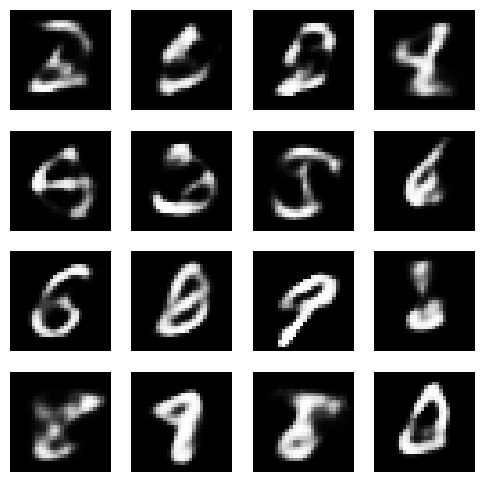

In [6]:
model.eval()

with torch.no_grad():
    z = torch.randn(16, 20).to(device)
    samples = model.decode(z).cpu()

    samples = samples.view(16, 28, 28)

    fig, axes = plt.subplots(4, 4, figsize=(6, 6))
    for i, ax in enumerate(axes.flat):
        ax.imshow(samples[i], cmap="gray")
        ax.axis("off")
    plt.show()